In [16]:
from sklearn.datasets import fetch_california_housing

In [17]:
house_data = fetch_california_housing(as_frame=True)
df = house_data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
# Classifying depedant and indepedant features

X = house_data.data
y = house_data.target
# print(X.head())
print(y)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


In [ ]:
# importing train_test_split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

(14448,)

In [20]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


In [22]:
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
regression = LinearRegression()
regression.fit(X_train,y_train)
y_pred = regression.predict(X_test)


In [24]:
mse = cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error",cv=5)
mse

array([-0.54787556, -0.500835  , -0.52045639, -0.51612252, -0.54883741])

In [25]:
r2 = r2_score(y_pred,y_test)
r2

0.3451339380943943

In [26]:
from sklearn.metrics import mean_squared_error
new_mse = mean_squared_error(y_test, y_pred)
new_mse

0.5305677824766757

In [27]:
# from sklearn.ensemble import RandomForestRegressor
# rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# rf_regressor.fit(X_train_scaled, y_train)
# y_pred_rf = rf_regressor.predict(X_test_scaled)
# new_mse = mean_squared_error(y_test, y_pred_rf)
# new_r2 = r2_score(y_test, y_pred_rf)
# print(new_mse)
# print(new_r2)

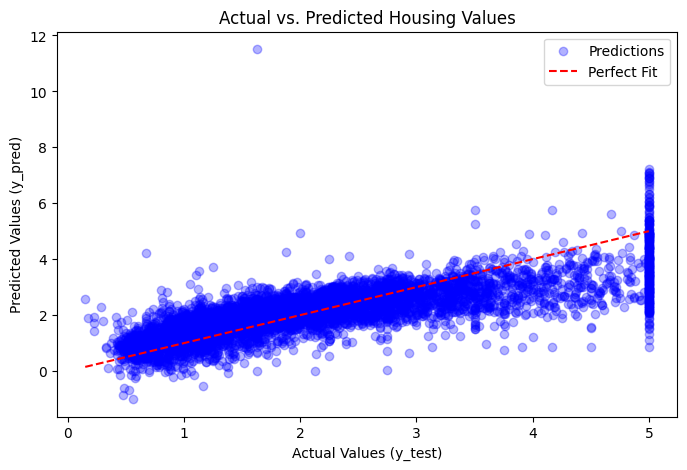

In [34]:
import matplotlib.pyplot as plt
y_pred = regression.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.3, label='Predictions')

perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label='Perfect Fit')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Housing Values')
plt.legend()
plt.show()